# Exercise 9.6: Handwritten Digit Recognition with kNN

**Task:** Given enough handwritten samples, use a kNN classifier to identify a *new* character from its visual similarity to the sample data.

**Dataset/code:** [pbharrin/machinelearninginaction](https://github.com/pbharrin/machinelearninginaction), Chapter 2 (`kNN.py`, `digits.zip`).

**Note:** the dataset contains only the digits 0-9, so the classifier recognises numbers, not letters. The same method would recognise letters if letter samples were supplied in the same format.

In [ ]:
!git clone -q https://github.com/pbharrin/machinelearninginaction.git 2>/dev/null || echo

## 1. Setup: move to Ch02 and extract the dataset

In [ ]:
import os, zipfile

os.chdir('/content/machinelearninginaction/Ch02')
print('Working directory:', os.getcwd())

# digits.zip contains trainingDigits/ and testDigits/
if not os.path.isdir('trainingDigits'):
    with zipfile.ZipFile('digits.zip') as z:
        z.extractall('.')
# The book's kNN.py is Python 2; patch it so it runs under Python 3
import re
src = open('kNN.py').read()
if 'iteritems' in src or re.search(r'^\s*print [^(]', src, re.M):
    src = src.replace('.iteritems()', '.items()')
    src = re.sub(r'^(\s*)print (.+)$', r'\1print(\2)', src, flags=re.M)
    open('kNN.py', 'w').write(src)
    print('Patched kNN.py for Python 3')

print('Training files:', len(os.listdir('trainingDigits')))
print('Test files    :', len(os.listdir('testDigits')))

Working directory: /content/machinelearninginaction/Ch02
Patched kNN.py for Python 3
Training files: 1934
Test files    : 946


## 2. How the data and the method work

- Each sample is a **32x32 text image** of 0s and 1s (1 = ink). The file name gives the label, e.g. `3_45.txt` is the 45th sample of digit 3.
- `img2vector` flattens the image into a **1x1024 vector**.
- To classify a new image, kNN computes the **Euclidean distance** to every training vector, takes the **k nearest**, and returns the **majority label** among them.

In [ ]:
import kNN

# Look at one sample as an image and as a vector
sample = 'testDigits/0_13.txt'
print(open(sample).read())
vec = kNN.img2vector(sample)
print('Vector shape:', vec.shape)

00000000000000111100000000000000
00000000000011111110000000000000
00000000000111111111000000000000
00000000001111111111100000000000
00000000001111111111100000000000
00000000111111111111110000000000
00000000011111111111111000000000
00000000111111110111111000000000
00000001111110000000111100000000
00000001111110000000011100000000
00000011111110000000011100000000
00000011111100000000011100000000
00000011111100000000011100000000
00000001111100000000001111000000
00000001111000000000000111000000
00000011110000000000000111000000
00000011110000000000000111000000
00000011110000000000000111000000
00000011110000000000000111000000
00000011110000000000000111000000
00000000111000000000000011100000
00000000111000000000000011100000
00000000111100000000000111100000
00000000111100000000000111100000
00000000111110000000011111100000
00000000011111000000111111000000
00000000011111111111111110000000
00000000001111111111111111000000
00000000000111111111111111000000
00000000000111111111111110000000
0000000000

## 3. Build the training set

In [ ]:
import numpy as np
from os import listdir

def load_dataset(folder):
    files = sorted(listdir(folder))
    X = np.zeros((len(files), 1024))
    y = []
    for i, f in enumerate(files):
        X[i, :] = kNN.img2vector(f'{folder}/{f}')
        y.append(int(f.split('_')[0]))
    return X, y, files

X_train, y_train, _ = load_dataset('trainingDigits')
X_test, y_test, test_files = load_dataset('testDigits')
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (1934, 1024)  Test: (946, 1024)


## 4. Classify a NEW, unseen sample

In [ ]:
def predict_digit(path, k=3):
    v = kNN.img2vector(path)
    return kNN.classify0(v, X_train, y_train, k)

# Pick a few test images that were not used for training
for f in ['testDigits/0_13.txt', 'testDigits/5_20.txt', 'testDigits/8_7.txt']:
    if os.path.exists(f):
        print(f'{f}: predicted {predict_digit(f)}, actual {f.split("/")[-1].split("_")[0]}')

testDigits/0_13.txt: predicted 0, actual 0
testDigits/5_20.txt: predicted 5, actual 5
testDigits/8_7.txt: predicted 8, actual 8


### Classifying your own handwriting
To test a truly new character, draw a digit, resize to 32x32, threshold to 0/1 and save it as a text file with 32 rows of 32 characters. The helper below does this from an image file (PNG/JPG, dark ink on light background).

In [ ]:
from PIL import Image

def image_to_txt(img_path, out_path='my_digit.txt', threshold=128):
    img = Image.open(img_path).convert('L').resize((32, 32))
    arr = (np.array(img) < threshold).astype(int)      # dark pixels -> 1
    with open(out_path, 'w') as f:
        for row in arr:
            f.write(''.join(map(str, row)) + '\n')
    return out_path

# Example (upload an image first, e.g. via the Colab file panel):
# path = image_to_txt('my_digit.png')
# print('Prediction:', predict_digit(path, k=3))

## 5. Evaluate on the full test set

In [ ]:
def evaluate(k):
    errors = sum(kNN.classify0(X_test[i], X_train, y_train, k) != y_test[i]
                 for i in range(len(y_test)))
    return errors, errors / len(y_test)

errors, rate = evaluate(3)
print(f'k=3: {errors} errors out of {len(y_test)}, error rate {rate:.4f}, accuracy {1-rate:.2%}')

k=3: 11 errors out of 946, error rate 0.0116, accuracy 98.84%


## 6. Effect of k

k= 1  error rate=0.0137
k= 3  error rate=0.0116
k= 5  error rate=0.0180
k= 7  error rate=0.0233
k= 9  error rate=0.0222
k=11  error rate=0.0201


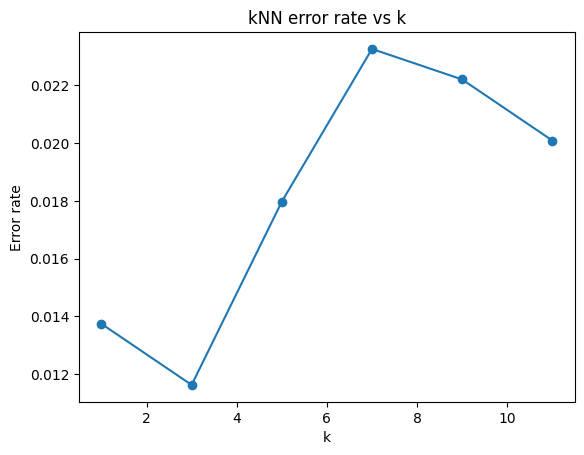

In [ ]:
import matplotlib.pyplot as plt

ks = [1, 3, 5, 7, 9, 11]
rates = [evaluate(k)[1] for k in ks]
for k, r in zip(ks, rates):
    print(f'k={k:2d}  error rate={r:.4f}')

plt.plot(ks, rates, marker='o')
plt.xlabel('k'); plt.ylabel('Error rate'); plt.title('kNN error rate vs k')
plt.show()

## 7. Which digits get confused?

In [ ]:
from collections import Counter

conf = Counter()
for i in range(len(y_test)):
    p = kNN.classify0(X_test[i], X_train, y_train, 3)
    if p != y_test[i]:
        conf[(y_test[i], p)] += 1
print('(actual, predicted): count')
for pair, n in conf.most_common():
    print(pair, n)

(actual, predicted): count
(8, 1) 2
(1, 7) 1
(3, 9) 1
(5, 3) 1
(5, 6) 1
(8, 6) 1
(8, 3) 1
(9, 1) 1
(9, 7) 1
(9, 5) 1
